## 🚢 Titanic Survival Analysis — Insight-Driven Visualization

📦 Dataset: Seaborn Built-in Titanic \
🎯 Goal: Uncover survival patterns via 13 plot types \
👤 Author: D_Manglam

### 🔍 Phase 1 — Setup + Raw Exploration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset("titanic")

In [3]:
df.shape

(891, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.columns


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [8]:
df["deck"].shape[0]

891

In [9]:
deck_null_percentage = round((df["deck"].isnull().sum()/df["deck"].shape[0])*100,2)
print(deck_null_percentage)

77.22


In [10]:
df[["alive", "survived"]]

,alive,survived
0,no,0
1,yes,1
2,yes,1
3,yes,1
4,no,0
...,...,...
886,no,0
887,yes,1
888,no,0
889,yes,1


In [11]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [12]:
df[["embarked", "embark_town"]]

,embarked,embark_town
0,S,Southampton
1,C,Cherbourg
2,S,Southampton
3,S,Southampton
4,S,Southampton
...,...,...
886,S,Southampton
887,S,Southampton
888,S,Southampton
889,C,Cherbourg


### 1. Drop high-null and redundant columns

In [4]:
df.drop(columns=["deck", "alive", "embark_town"], inplace=True)

In [5]:
df.dropna(inplace=True)

In [15]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'alone'],
      dtype='object')

### 2. Fill age nulls with median

In [6]:
df["age"] = df["age"].fillna(df["age"].median())

In [17]:
print(df["age"].isnull().sum())

0


### 3. Confirm shape

In [18]:
df.shape

(712, 12)

### 4. Save to `processed/`

In [42]:
df.to_csv('../data/processed/titanic_cleaned.csv', index=False)

In [37]:
import os
os.getcwd()

'D:\\Data_Science\\01_Practice\\07_Data_Visualization\\notebooks'

In [43]:
print(os.path.exists('../data/processed/'))

True


### 📊 Phase 2 — Univariate Analysis

**Goal:** Understand the distribution of individual variables before comparing them.  
**Plots covered:** `histplot`, `kdeplot`, `countplot`  
**Key question:** What does each variable look like in isolation?

> 💡 Univariate = one variable at a time. No comparisons yet.
> We're building intuition about shape, skew, and frequency before layering complexity.

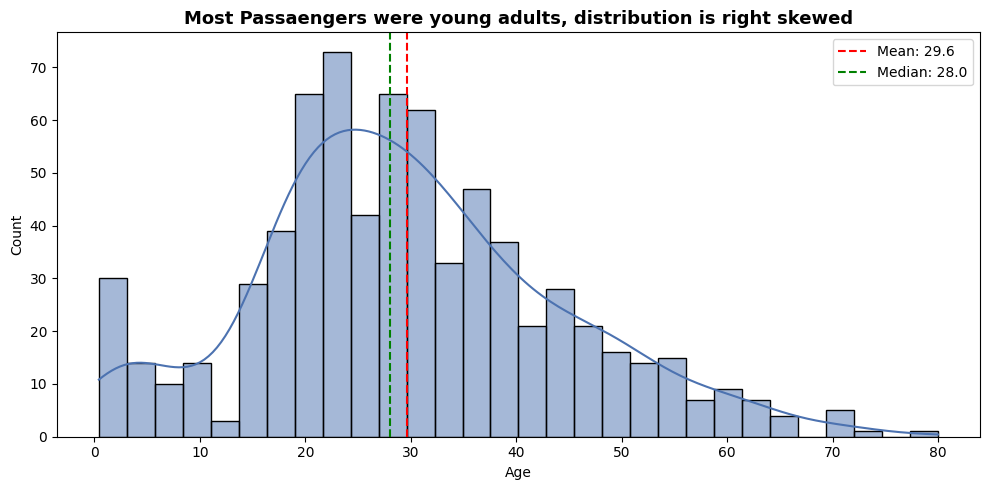

In [21]:
# histplot: best for numerical distribution with bin-level detail + kde overlay
fig, ax = plt.subplots(figsize=(10,5))

sns.histplot(
    data=df,
    x="age",
    kde=True,
    color="#4c72b0",
    bins=30,
    ax=ax
)

ax.axvline(df["age"].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: {df["age"].mean():.1f}")
ax.axvline(df["age"].median(), color="green", linestyle="--", linewidth=1.5, label=f"Median: {df["age"].median():.1f}")

ax.set_title("Most Passaengers were young adults, distribution is right skewed", fontsize=13, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/01_age_distribution.png", dpi=150)
plt.show()

In [23]:
df[["fare", "survived"]]

,fare,survived
0,7.2500,0
1,71.2833,1
2,7.9250,1
3,53.1000,1
4,8.0500,0
...,...,...
885,29.1250,0
886,13.0000,0
887,30.0000,1
889,30.0000,1


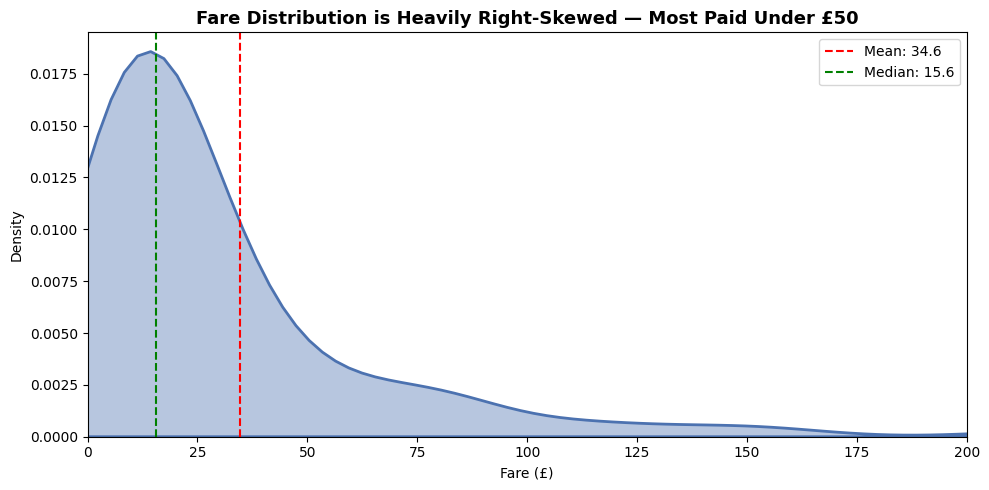

In [25]:
# kdeplot: best for visualizing smooth shape of a distribution without bin noise
fig, ax = plt.subplots(figsize=(10,5))

sns.kdeplot(
    data=df,
    x="fare",
    color="#4c72b0",
    fill=True,
    alpha=0.4,
    linewidth=2,
    ax=ax
)

ax.set_xlim(0,200)
ax.axvline(df["fare"].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: {df["fare"].mean():.1f}")
ax.axvline(df["fare"].median(), color="green", linestyle="--", linewidth=1.5, label=f"Median: {df["fare"].median():.1f}")

ax.set_title("Fare Distribution is Heavily Right-Skewed — Most Paid Under £50", fontsize=13, fontweight="bold")

ax.set_xlabel("Fare (£)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/02_fare_distribution.png", dpi=150)
plt.show()

C:\Users\mangl\AppData\Local\Temp\ipykernel_40356\1074001961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


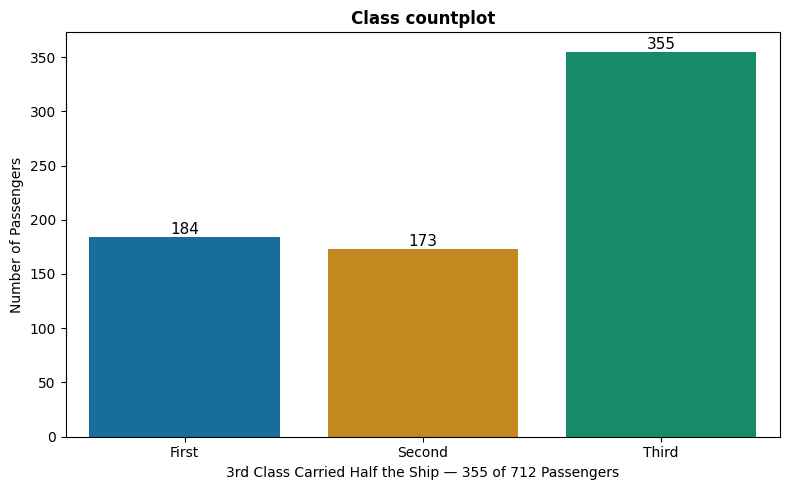

In [27]:
# countplot: best for shwoing frequency of categorical variables
fig, ax = plt.subplots(figsize=(8,5))

sns.countplot(
    data=df,
    x="class",
    palette="colorblind",
    order=["First", "Second", "Third"],
    ax=ax
)

# annotate count on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

ax.set_title("Class countplot", fontsize=12, fontweight="bold")

ax.set_xlabel("3rd Class Carried Half the Ship — 355 of 712 Passengers")
ax.set_ylabel("Number of Passengers")

plt.tight_layout()
plt.savefig("../outputs/figures/03_class_distribution.png", dpi=150)
plt.show()

In [ ]:
from warnings import showwarning

### 📊 Phase 3 — Bivariate Analysis

**Goal:** Uncover how survival changes when a second variable is introduced.  
**Plots covered:** `barplot`, `boxplot`, `violinplot`, `stripplot`, `scatterplot`, `regplot`  
**Key question:** Which variables actually drove survival — age, fare, or class?

> 💡 Bivariate = two variables at a time. We're building the evidence chain.
> Every plot here adds one link: age → fare → class → survival.

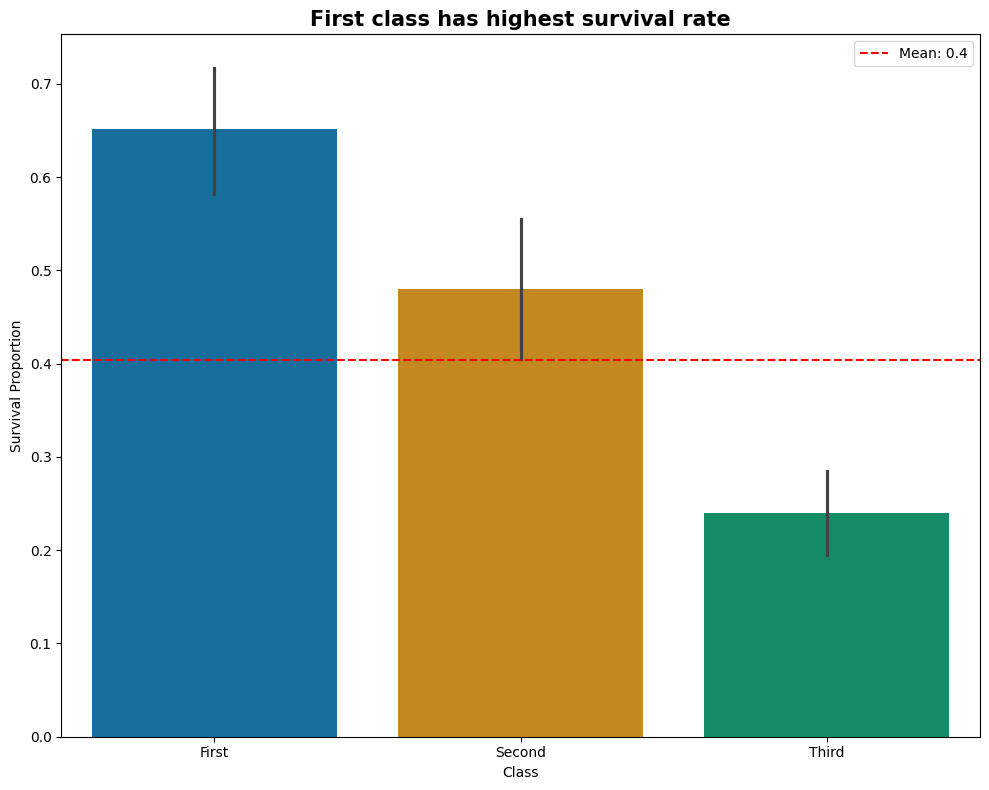

In [10]:
# barplot: best for comparing mean of a continuous/binary target across categories
fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(
    data=df,
    x="class",
    y="survived",
    order=["First", "Second", "Third"],
    hue="class",
    palette="colorblind", 
    legend=False,
    ax=ax
)

ax.axhline(df["survived"].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: {df['survived'].mean():.1f}")
ax.legend()

ax.set_title("First class has highest survival rate", fontsize=15, fontweight="bold") 
ax.set_xlabel("Class")
ax.set_ylabel("Survival Proportion")

plt.tight_layout()
plt.savefig("../outputs/figures/04_survival_rate_by_class.png", dpi=150) 
plt.show()

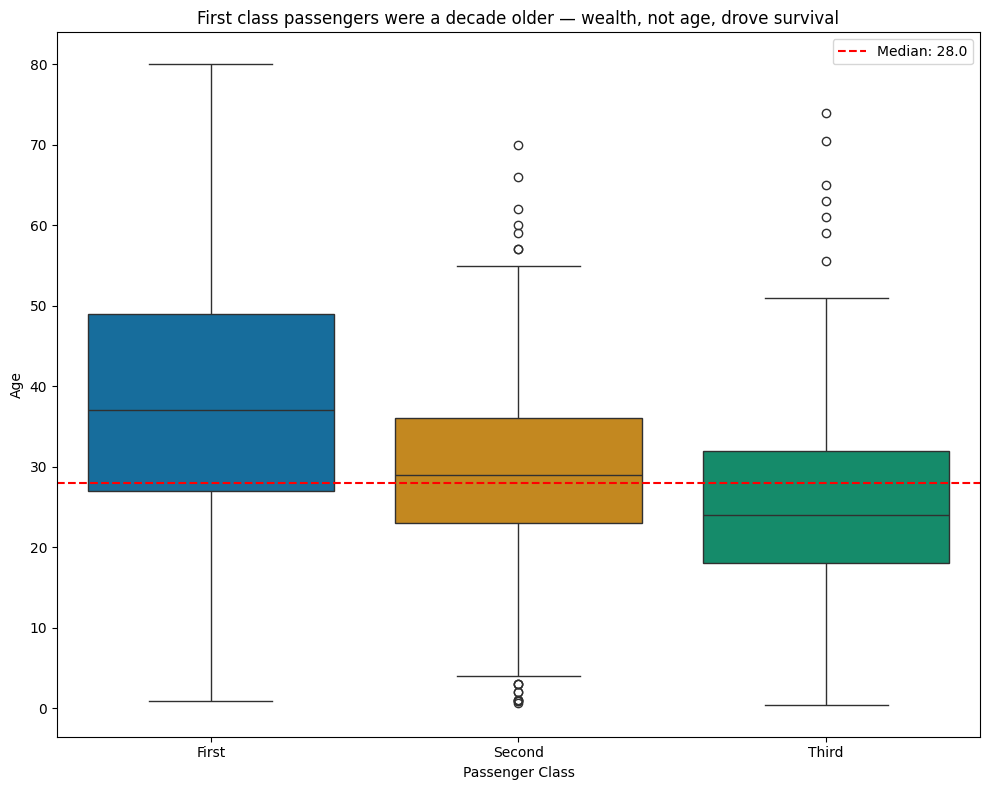

In [12]:
# boxplot: best for understanding distribution of continous variable
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(
    data=df,
    x="class",
    y="age",
    order=["First", "Second", "Third"],
    hue="class",
    legend=False,
    palette="colorblind",
    ax=ax
)

ax.axhline(df["age"].median(), color="red", linestyle="--", linewidth=1.5, label=f"Median: {df['age'].median():.1f}")
ax.legend()

ax.set_title("First class passengers were a decade older — wealth, not age, drove survival")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Age")

plt.tight_layout()
plt.savefig("../outputs/figures/05_age_distribution_by_class.png", dpi=150)
plt.show()

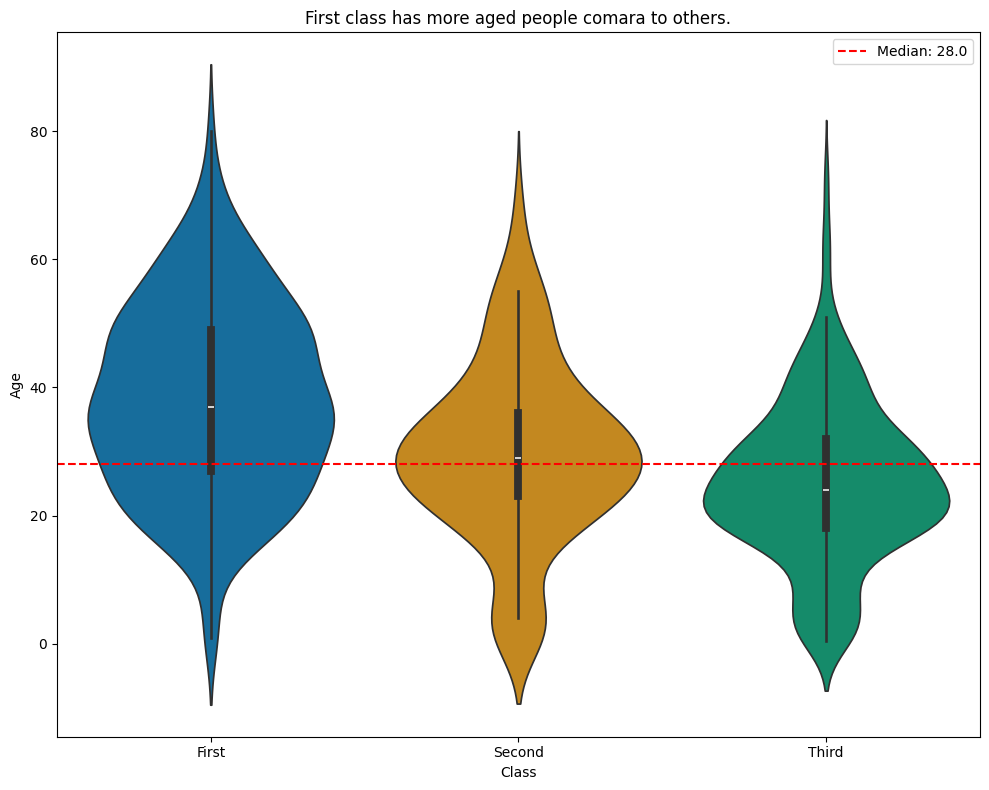

In [ ]:
# violineplot: it is best to know what box plot hides like the density of people in particular range
fig,ax = plt.subplots(figsize=(10,8))

sns.violinplot(
    data=df,
    x="class",
    y="age",
    order=["First", "Second", "Third"],
    hue="class",
    legend=False,
    palette="colorblind",
    inner="box",
    ax=ax
)

ax.axhline(df["age"].median(), color="red", linestyle="--", linewidth=1.5, label=f"Median: {df['age'].median():.1f}")
ax.legend()

ax.set_title("First class has more aged people comara to others.")
ax.set_xlabel("Class")
ax.set_ylabel("Age")

plt.tight_layout()
plt.savefig("../outputs/figures/06_age_distribution_violin.png", dpi=150)
plt.show()



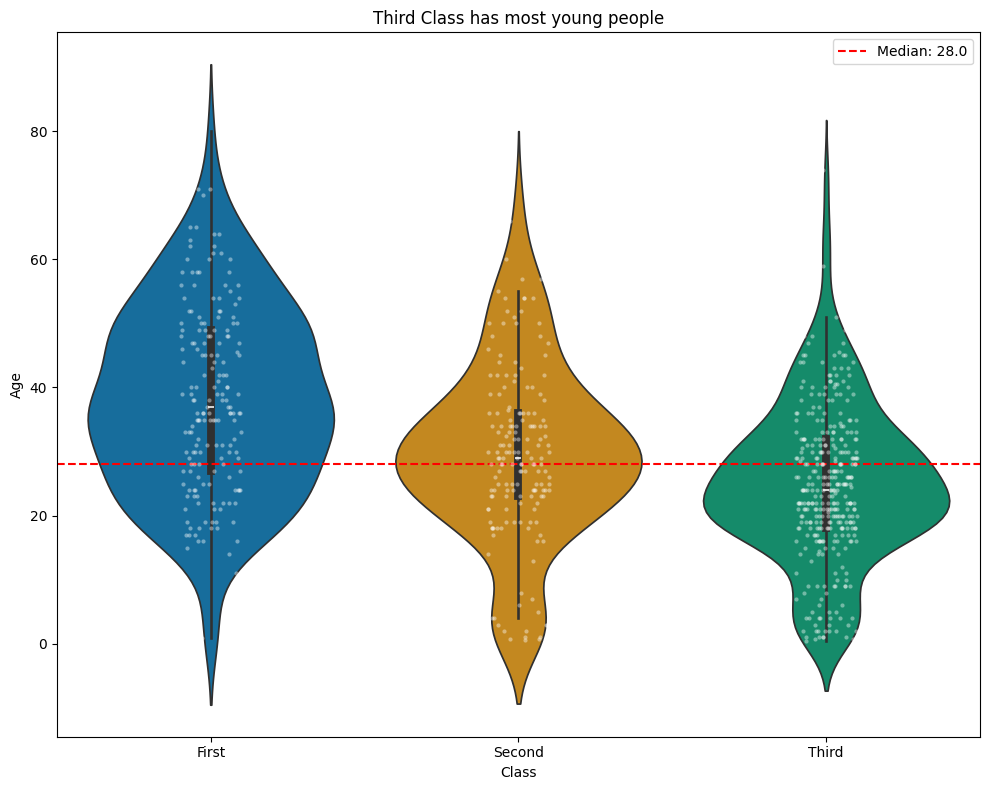

In [ ]:
# stripplot: when you want show exact spread of data points (usefull for small datset where individual points matters)

fig,ax = plt.subplots(figsize=(10,8))

sns.violinplot(
    data=df,
    x="class",
    y="age",
    order=["First", "Second", "Third"],
    hue="class",
    legend=False,
    palette="colorblind",
    inner="box",
    ax=ax
)

sns.stripplot(
    data=df,
    x="class",
    y="age",
    order=["First", "Second", "Third"],
    color="white",
    legend=False,
    jitter=True,
    size=3,
    alpha=0.4,
    ax=ax
)

ax.axhline(df["age"].median(), color="red", linestyle="--", linewidth=1.5, label=f"Median: {df['age'].median():.1f}")
ax.legend()

ax.set_title("Third Class has most young people")
ax.set_xlabel("Class")
ax.set_ylabel("Age")

plt.tight_layout()
plt.savefig("../outputs/figures/07_age_stripplot_overlay.png", dpi=150)
plt.show()

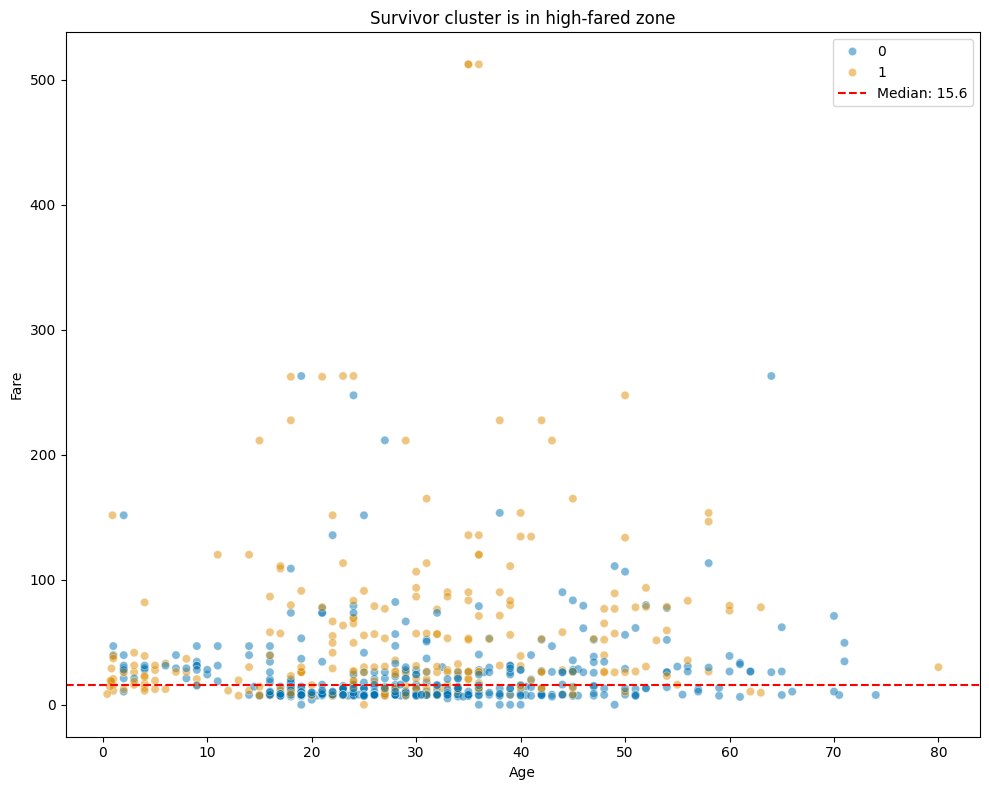

In [10]:
# scatterplot: to get the clustering analysis of variable scatteplot is best. 

fig,ax = plt.subplots(figsize=(10,8))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    palette="colorblind",
    alpha=0.5,
    ax=ax
)

ax.axhline(df["fare"].median(), color="red", linestyle="--", linewidth=1.5, label=f"Median: {df['fare'].median():.1f}")
ax.legend()
ax.set_title("Survivor cluster is in high-fared zone")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")

plt.tight_layout()
plt.savefig("../outputs/figures/08_age_vs_fare_scatter.png", dpi=150)
plt.show()

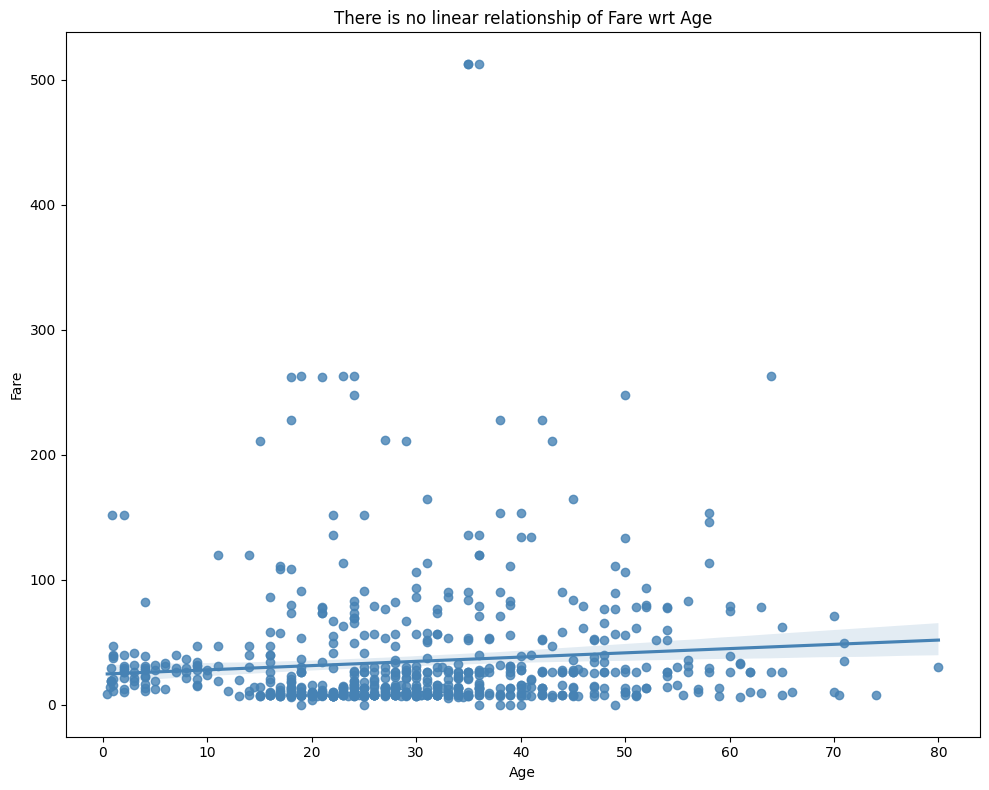

In [12]:
# regplot: it is best to use regplot to get wheather two attributes are correlated with each other or not
fig, ax = plt.subplots(figsize=(10,8))

sns.regplot(
    data=df,
    x="age",
    y="fare",
    scatter=True,
    ci=95,
    color="steelblue",
    ax=ax
)

ax.set_title("There is no linear relationship of Fare wrt Age")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")

plt.tight_layout()
plt.savefig("../outputs/figures/09_age_fare_regplot.png", dpi=150)
plt.show()